In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# ============== 날짜 범위 설정 ==============
start_date = '2026-03-13'  # 시작 날짜 (None으로 설정하면 전체)
end_date = '2026-03-18'    # 종료 날짜 (None으로 설정하면 전체)
# =========================================

# ============== 폰트 설정 ==============
FONTSIZE = 20  # 모든 폰트 크기 통일
# =====================================

# ============== 제외할 인스턴스 타입 ==============
# EXCLUDE_INSTANCES = ['g6e.xlarge', 'g6.xlarge']
EXCLUDE_INSTANCES = []
# ============================================

In [2]:
# CSV 파일 읽기 (여러 날짜 파일을 읽어서 merge)
csv_files = [
    '2026-03-13.csv',
    '2026-03-14.csv',
    '2026-03-15.csv',
    '2026-03-16.csv',
    '2026-03-17.csv',
    '2026-03-18.csv',
    # '2026-03-19.csv',
]

df_list = []
for f in csv_files:
    tmp = pd.read_csv(f)
    df_list.append(tmp)
    print(f"  {f}: {len(tmp)} rows")

df = pd.concat(df_list, ignore_index=True)
print(f"\nMerged total: {len(df)} rows")

# RequestDateTime을 datetime 타입으로 변환
df['RequestDateTime'] = pd.to_datetime(df['RequestDateTime'])

# 날짜 범위 필터링
df_filtered = df.copy()
if start_date is not None:
    df_filtered = df_filtered[df_filtered['RequestDateTime'] >= start_date]
if end_date is not None:
    df_filtered = df_filtered[df_filtered['RequestDateTime'] <= end_date + ' 23:59:59']

# 제외할 인스턴스 타입 필터링
df_filtered = df_filtered[~df_filtered['InstanceType'].isin(EXCLUDE_INSTANCES)]

print(f"날짜 범위: {start_date} ~ {end_date}")
print(f"제외된 인스턴스: {EXCLUDE_INSTANCES}")
print(f"필터링 후 데이터 Shape: {df_filtered.shape}\n")

# 존재하는 모든 인스턴스 타입 추출
instance_types = sorted(df_filtered['InstanceType'].unique())
# instance_types = ['g5.xlarge', 'g5.12xlarge', 'g6e.12xlarge', 'p4d.24xlarge', 'p5.48xlarge']
instance_types = ['g5.xlarge', 'g6.xlarge','g6e.xlarge','g5.12xlarge', 'g6.12xlarge', 'g6e.12xlarge','p4d.24xlarge','p5.48xlarge', 'p6-b200.48xlarge']
print(f"인스턴스 타입: {instance_types}\n")

  2026-03-13.csv: 1215 rows
  2026-03-14.csv: 1296 rows
  2026-03-15.csv: 1296 rows
  2026-03-16.csv: 1296 rows
  2026-03-17.csv: 1296 rows
  2026-03-18.csv: 1296 rows

Merged total: 7695 rows
날짜 범위: 2026-03-13 ~ 2026-03-18
제외된 인스턴스: []
필터링 후 데이터 Shape: (7695, 7)

인스턴스 타입: ['g5.xlarge', 'g6.xlarge', 'g6e.xlarge', 'g5.12xlarge', 'g6.12xlarge', 'g6e.12xlarge', 'p4d.24xlarge', 'p5.48xlarge', 'p6-b200.48xlarge']



In [3]:
# GPU 개수 및 모델명 매핑
gpu_info = {
    'g5.xlarge': {'count': 1, 'model': 'A10G'},
    'g6.xlarge': {'count': 1, 'model': 'L4'},
    'g6e.xlarge': {'count': 1, 'model': 'L40S'},
    'g5.12xlarge': {'count': 4, 'model': 'A10G'},
    'g6.12xlarge': {'count': 4, 'model': 'L4'},
    'g6e.12xlarge': {'count': 4, 'model': 'L40S'},
    'p4d.24xlarge': {'count': 8, 'model': 'A100'},
    'p5.48xlarge': {'count': 8, 'model': 'H100'},
    'p6-b200.48xlarge': {'count': 8, 'model': 'B200'},
}

# 매핑에 없는 인스턴스 타입은 기본값으로 설정
for instance_type in instance_types:
    if instance_type not in gpu_info:
        gpu_info[instance_type] = {'count': 1, 'model': 'Unknown'}
        print(f"Warning: {instance_type}의 GPU 정보를 알 수 없어 기본값으로 설정했습니다.")

g5.xlarge (A10G): Total records = 855, Success GPU sum = 8996, Fail GPU sum = 8104
g6.xlarge (L4): Total records = 855, Success GPU sum = 12320, Fail GPU sum = 4780
g6e.xlarge (L40S): Total records = 855, Success GPU sum = 10458, Fail GPU sum = 6642
g5.12xlarge (A10G): Total records = 855, Success GPU sum = 2872, Fail GPU sum = 14228
g6.12xlarge (L4): Total records = 855, Success GPU sum = 13812, Fail GPU sum = 3288
g6e.12xlarge (L40S): Total records = 855, Success GPU sum = 5056, Fail GPU sum = 12044
p4d.24xlarge (A100): Total records = 855, Success GPU sum = 5360, Fail GPU sum = 8320
p5.48xlarge (H100): Total records = 855, Success GPU sum = 4680, Fail GPU sum = 9000
p6-b200.48xlarge (B200): Total records = 855, Success GPU sum = 0, Fail GPU sum = 13680

그래프가 'figures/spot_availability.pdf'로 저장되었습니다.


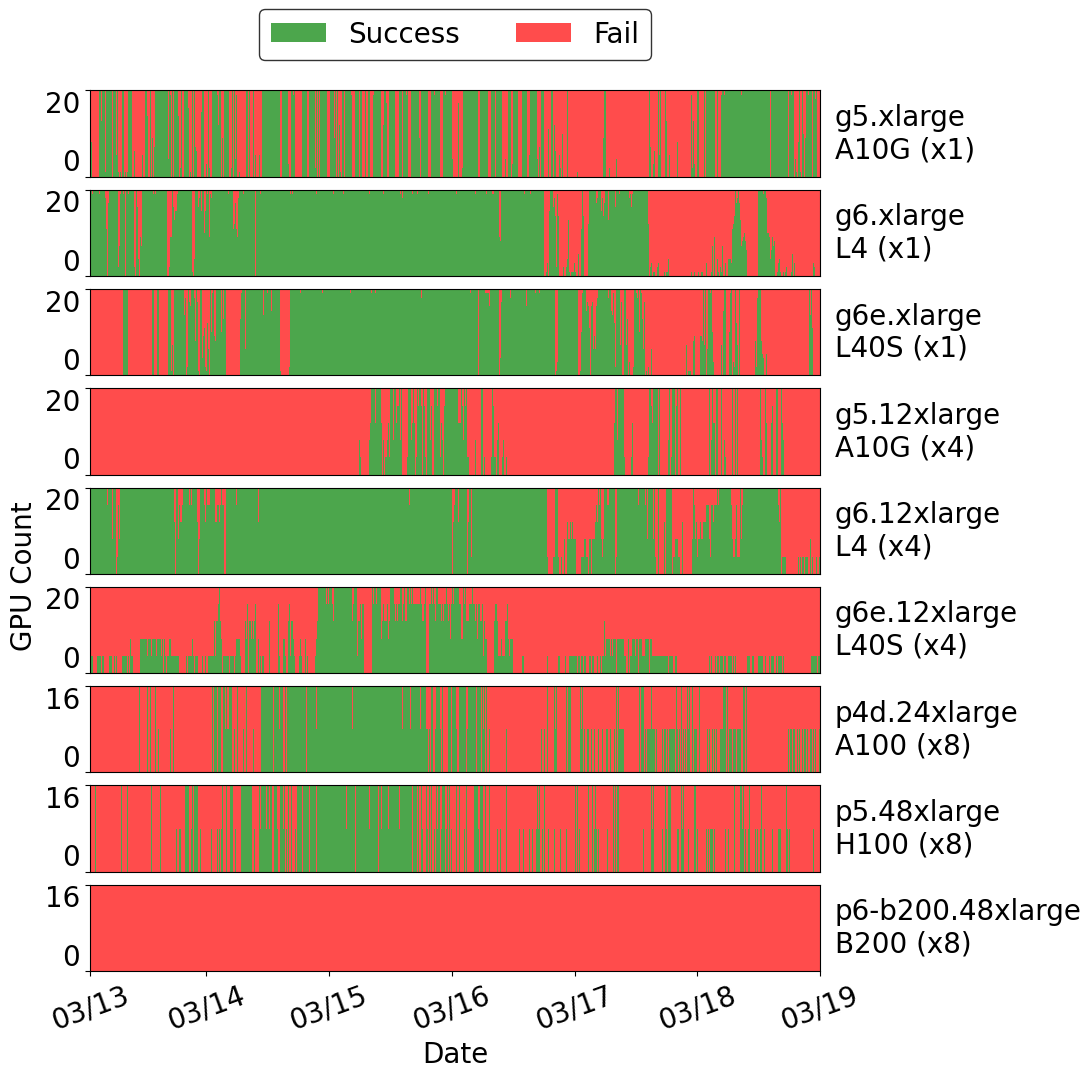


인스턴스 타입별 데이터 수:
InstanceType
g5.12xlarge         855
g5.xlarge           855
g6.12xlarge         855
g6.xlarge           855
g6e.12xlarge        855
g6e.xlarge          855
p4d.24xlarge        855
p5.48xlarge         855
p6-b200.48xlarge    855
Name: count, dtype: int64


In [4]:
# 모든 인스턴스를 각각 stacked bar chart로 그리기
num_instances = len(instance_types)
fig, axes = plt.subplots(num_instances, 1, figsize=(10, 1.2 * num_instances))

import os
os.makedirs('figures', exist_ok=True)

# 인스턴스가 1개만 있는 경우 axes를 리스트로 변환
if num_instances == 1:
    axes = [axes]

for idx, instance_type in enumerate(instance_types):
    instance_data = df_filtered[df_filtered['InstanceType'] == instance_type].sort_values('RequestDateTime').reset_index(drop=True)
    
    # GPU 정보 가져오기
    gpu_count = gpu_info[instance_type]['count']
    gpu_model = gpu_info[instance_type]['model']
    
    # p4d, p5, p6 계열은 y축 최대 16, 나머지는 20
    if instance_type.startswith('p'):
        y_max = 16
    else:
        y_max = 20
    
    # GPU 개수를 곱한 값 계산
    success_gpu = instance_data['Success'] * gpu_count
    fail_gpu = instance_data['Fail'] * gpu_count
    
    # 결손치 보정: success + fail이 y_max에 미달하면 fail로 채움
    total_gpu = success_gpu + fail_gpu
    deficit = y_max - total_gpu
    deficit = deficit.clip(lower=0)  # 음수는 0으로
    fail_gpu = fail_gpu + deficit
    
    ax = axes[idx]
    
    # Success를 초록색 바로, Fail을 빨간색 바로 쌓아서 그리기 (alpha 적용)
    x = range(len(instance_data))
    ax.bar(x, success_gpu, 
           color='green', label='Success', edgecolor='none', width=1.0, alpha=0.7)
    ax.bar(x, fail_gpu, 
           bottom=success_gpu, color='red', label='Fail', edgecolor='none', width=1.0, alpha=0.7)
    
    # x축 범위 설정 (공백 제거)
    ax.set_xlim(-0.5, len(instance_data) - 0.5)
    
    # x축 레이블 설정: 날짜 기반 tick
    # 각 날짜의 00:00 시점에 해당하는 인덱스 위치를 찾아서 tick으로 사용
    tick_positions = []
    tick_labels = []
    dates = instance_data['RequestDateTime'].dt.date.unique()
    for d in sorted(dates):
        # 해당 날짜의 첫 번째 데이터 포인트 인덱스
        mask = instance_data['RequestDateTime'].dt.date == d
        if mask.any():
            first_idx = instance_data[mask].index[0]
            tick_positions.append(first_idx)
            tick_labels.append(pd.Timestamp(d).strftime('03/%d'))
    # 마지막 날짜 다음날 경계 (데이터 끝)도 추가
    tick_positions.append(len(instance_data) - 1)
    last_date = sorted(dates)[-1]
    tick_labels.append((pd.Timestamp(last_date) + pd.Timedelta(days=1)).strftime('03/%d'))
    
    ax.set_xticks(tick_positions)
    
    # 마지막 subplot이 아닌 경우 x축 레이블 숨김
    if idx < len(instance_types) - 1:
        ax.set_xticklabels([])
        ax.tick_params(axis='x', which='both', length=0)
    else:
        # 마지막 subplot만 x축 레이블 표시
        ax.set_xticklabels(tick_labels, rotation=20, ha='center', fontsize=FONTSIZE)
        ax.set_xlabel('Date', fontsize=FONTSIZE)
    
    # 제목을 오른쪽에 텍스트로 배치 (y축 오른쪽 영역)
    ax.text(1.02, 0.5, f'{instance_type}\n{gpu_model} (x{gpu_count})', 
            transform=ax.transAxes, fontsize=FONTSIZE, 
            va='center', ha='left')
    
    # 첫 번째 subplot에만 legend 표시 (위치 조정: 살짝 왼쪽으로)
    if idx == 0:
        legend = ax.legend(loc='upper center', bbox_to_anchor=(0.5,2.1), fontsize=FONTSIZE, ncol=2, 
                          edgecolor='black', fancybox=True)
        legend.get_frame().set_linewidth(1.0)
    
    # y축 범위 설정
    ax.set_ylim(0, y_max)
    
    # y축 tick: 0과 y_max만 표시
    ax.set_yticks([0, y_max])
    
    ax.tick_params(axis='y', labelsize=FONTSIZE)
    
    # y축 tick label의 vertical alignment 조정
    plt.draw()
    for tick in ax.yaxis.get_major_ticks():
        tick_value = tick.get_loc()
        if tick_value == 0:
            tick.label1.set_va('bottom')
            tick.label1.set_y(tick.label1.get_position()[1] - 2)
        elif tick_value == y_max:
            tick.label1.set_va('top')
    
    print(f"{instance_type} ({gpu_model}): Total records = {len(instance_data)}, Success GPU sum = {success_gpu.sum():.0f}, Fail GPU sum = {fail_gpu.sum():.0f}")

# 공통 y축 레이블을 figure 중앙에 추가
fig.text(0.04, 0.47, 'GPU Count', va='center', rotation='vertical', fontsize=FONTSIZE)

# subplot 간격을 타이트하게 조정
plt.tight_layout()
plt.subplots_adjust(left=0.12, right=0.85, hspace=0.15)

# PDF로 저장
output_filename = 'figures/spot_availability.pdf'
plt.savefig(output_filename, format='pdf', bbox_inches='tight', dpi=300)
print(f"\n그래프가 '{output_filename}'로 저장되었습니다.")

plt.show()

print(f"\n인스턴스 타입별 데이터 수:")
print(df_filtered['InstanceType'].value_counts())

UTC-7 기준 날짜 범위: 2026-03-13 ~ 2026-03-17
필터링 후 데이터 Shape: (6480, 7)

g5.xlarge (A10G): Total records = 720, Success GPU sum = 6905, Fail GPU sum = 7495
g6.xlarge (L4): Total records = 720, Success GPU sum = 11184, Fail GPU sum = 3216
g6e.xlarge (L40S): Total records = 720, Success GPU sum = 10151, Fail GPU sum = 4249
g5.12xlarge (A10G): Total records = 720, Success GPU sum = 2612, Fail GPU sum = 11788
g6.12xlarge (L4): Total records = 720, Success GPU sum = 12164, Fail GPU sum = 2236
g6e.12xlarge (L40S): Total records = 720, Success GPU sum = 4832, Fail GPU sum = 9568
p4d.24xlarge (A100): Total records = 720, Success GPU sum = 5096, Fail GPU sum = 6424
p5.48xlarge (H100): Total records = 720, Success GPU sum = 4392, Fail GPU sum = 7128
p6-b200.48xlarge (B200): Total records = 720, Success GPU sum = 0, Fail GPU sum = 11520

그래프가 'figures/spot_availability_uswest2.pdf'로 저장되었습니다.


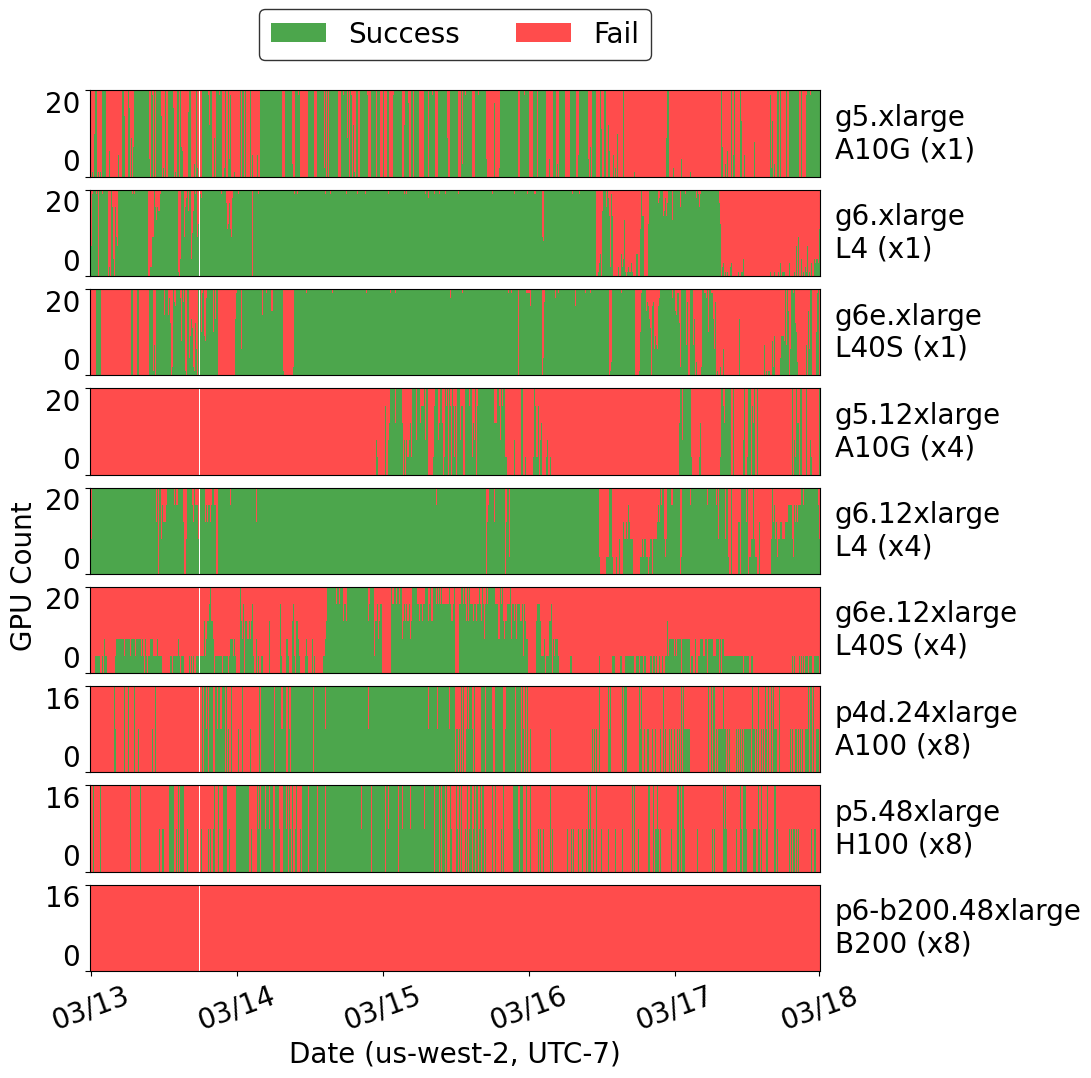

In [5]:
# ============== us-west-2 (UTC-7) 기준 날짜 범위 설정 ==============
pdt_start_date = '2026-03-13'  # UTC-7 기준 시작 날짜 (None으로 설정하면 전체)
pdt_end_date = '2026-03-17'    # UTC-7 기준 종료 날짜 (None으로 설정하면 전체)
# ================================================================

# RequestDateTime을 UTC-7로 변환
df_filtered_pdt = df_filtered.copy()
df_filtered_pdt['RequestDateTime'] = df_filtered_pdt['RequestDateTime'] - pd.Timedelta(hours=7)

# UTC-7 기준 날짜 범위 필터링
if pdt_start_date is not None:
    df_filtered_pdt = df_filtered_pdt[df_filtered_pdt['RequestDateTime'] >= pdt_start_date]
if pdt_end_date is not None:
    df_filtered_pdt = df_filtered_pdt[df_filtered_pdt['RequestDateTime'] <= pdt_end_date + ' 23:59:59']

print(f"UTC-7 기준 날짜 범위: {pdt_start_date} ~ {pdt_end_date}")
print(f"필터링 후 데이터 Shape: {df_filtered_pdt.shape}\n")

num_instances = len(instance_types)
fig, axes = plt.subplots(num_instances, 1, figsize=(10, 1.2 * num_instances))

if num_instances == 1:
    axes = [axes]

for idx, instance_type in enumerate(instance_types):
    instance_data = df_filtered_pdt[df_filtered_pdt['InstanceType'] == instance_type].sort_values('RequestDateTime').reset_index(drop=True)
    
    gpu_count = gpu_info[instance_type]['count']
    gpu_model = gpu_info[instance_type]['model']
    
    if instance_type.startswith('p'):
        y_max = 16
    else:
        y_max = 20
    
    success_gpu = instance_data['Success'] * gpu_count
    fail_gpu = instance_data['Fail'] * gpu_count
    
    total_gpu = success_gpu + fail_gpu
    deficit = y_max - total_gpu
    deficit = deficit.clip(lower=0)
    fail_gpu = fail_gpu + deficit
    
    ax = axes[idx]
    
    x = range(len(instance_data))
    ax.bar(x, success_gpu, 
           color='green', label='Success', edgecolor='none', width=1.0, alpha=0.7)
    ax.bar(x, fail_gpu, 
           bottom=success_gpu, color='red', label='Fail', edgecolor='none', width=1.0, alpha=0.7)
    
    ax.set_xlim(-0.5, len(instance_data) - 0.5)
    
    # x축 레이블 설정: 날짜 기반 tick (PDT 기준)
    tick_positions = []
    tick_labels = []
    dates = instance_data['RequestDateTime'].dt.date.unique()
    for d in sorted(dates):
        mask = instance_data['RequestDateTime'].dt.date == d
        if mask.any():
            first_idx = instance_data[mask].index[0]
            tick_positions.append(first_idx)
            tick_labels.append(pd.Timestamp(d).strftime('03/%d'))
    tick_positions.append(len(instance_data) - 1)
    last_date = sorted(dates)[-1]
    tick_labels.append((pd.Timestamp(last_date) + pd.Timedelta(days=1)).strftime('03/%d'))
    
    ax.set_xticks(tick_positions)
    
    if idx < len(instance_types) - 1:
        ax.set_xticklabels([])
        ax.tick_params(axis='x', which='both', length=0)
    else:
        ax.set_xticklabels(tick_labels, rotation=20, ha='center', fontsize=FONTSIZE)
        ax.set_xlabel('Date (us-west-2, UTC-7)', fontsize=FONTSIZE)
    
    ax.text(1.02, 0.5, f'{instance_type}\n{gpu_model} (x{gpu_count})', 
            transform=ax.transAxes, fontsize=FONTSIZE, 
            va='center', ha='left')
    
    if idx == 0:
        legend = ax.legend(loc='upper center', bbox_to_anchor=(0.5,2.1), fontsize=FONTSIZE, ncol=2, 
                          edgecolor='black', fancybox=True)
        legend.get_frame().set_linewidth(1.0)
    
    ax.set_ylim(0, y_max)
    ax.set_yticks([0, y_max])
    ax.tick_params(axis='y', labelsize=FONTSIZE)
    
    plt.draw()
    for tick in ax.yaxis.get_major_ticks():
        tick_value = tick.get_loc()
        if tick_value == 0:
            tick.label1.set_va('bottom')
            tick.label1.set_y(tick.label1.get_position()[1] - 2)
        elif tick_value == y_max:
            tick.label1.set_va('top')
    
    print(f"{instance_type} ({gpu_model}): Total records = {len(instance_data)}, Success GPU sum = {success_gpu.sum():.0f}, Fail GPU sum = {fail_gpu.sum():.0f}")

fig.text(0.04, 0.47, 'GPU Count', va='center', rotation='vertical', fontsize=FONTSIZE)

plt.tight_layout()
plt.subplots_adjust(left=0.12, right=0.85, hspace=0.15)

output_filename = 'figures/spot_availability_uswest2.pdf'
plt.savefig(output_filename, format='pdf', bbox_inches='tight', dpi=300)
print(f"\n그래프가 '{output_filename}'로 저장되었습니다.")

plt.show()

In [6]:
# p5.48xlarge의 GPU count가 16 이상이 되는 시간 비율 계산
# timewindow 방식: 각 datapoint부터 다음 datapoint까지 동일한 GPU 개수 유지

instance_type = 'p5.48xlarge'
gpu_count = gpu_info[instance_type]['count']

# p5.48xlarge 데이터 추출 및 시간순 정렬
p5_data = df_filtered[df_filtered['InstanceType'] == instance_type].sort_values('RequestDateTime').reset_index(drop=True)

# 각 데이터 포인트의 GPU 개수 계산 (Success * GPU count per instance)
p5_data['AvailableGPUs'] = p5_data['Success'] * gpu_count

# 각 데이터 포인트의 시간 간격 계산 (다음 데이터 포인트까지의 시간)
p5_data['TimeWindow'] = p5_data['RequestDateTime'].diff().shift(-1)

# 마지막 데이터 포인트의 경우, 이전 간격의 평균을 사용
if len(p5_data) > 1:
    avg_interval = p5_data['TimeWindow'].mean()
    p5_data.loc[p5_data.index[-1], 'TimeWindow'] = avg_interval

# TimeWindow를 초 단위로 변환
p5_data['TimeWindowSeconds'] = p5_data['TimeWindow'].dt.total_seconds()

# GPU count가 16 이상인 경우만 필터링
p5_above_16 = p5_data[p5_data['AvailableGPUs'] >= 16]

# 전체 시간과 16 이상인 시간 계산
total_time = p5_data['TimeWindowSeconds'].sum()
time_above_16 = p5_above_16['TimeWindowSeconds'].sum()

# 비율 계산
percentage_above_16 = (time_above_16 / total_time) * 100 if total_time > 0 else 0

print(f"=== p5.48xlarge GPU 가용성 분석 ===")
print(f"GPU per instance: {gpu_count}")
print(f"Total data points: {len(p5_data)}")
print(f"Total time covered: {total_time / 3600:.2f} hours")
print(f"\n--- GPU Count >= 16 Analysis ---")
print(f"Data points with >= 16 GPUs: {len(p5_above_16)}")
print(f"Time with >= 16 GPUs: {time_above_16 / 3600:.2f} hours")
print(f"Percentage of time with >= 16 GPUs: {percentage_above_16:.2f}%")
print(f"\n--- GPU Count Distribution ---")
for gpu_val in sorted(p5_data['AvailableGPUs'].unique()):
    subset = p5_data[p5_data['AvailableGPUs'] == gpu_val]
    time_val = subset['TimeWindowSeconds'].sum()
    pct = (time_val / total_time) * 100 if total_time > 0 else 0
    print(f"  {int(gpu_val):2d} GPUs: {time_val / 3600:6.2f} hours ({pct:5.2f}%)")

=== p5.48xlarge GPU 가용성 분석 ===
GPU per instance: 8
Total data points: 855
Total time covered: 142.60 hours

--- GPU Count >= 16 Analysis ---
Data points with >= 16 GPUs: 245
Time with >= 16 GPUs: 40.83 hours
Percentage of time with >= 16 GPUs: 28.64%

--- GPU Count Distribution ---
   0 GPUs:  85.93 hours (60.26%)
   8 GPUs:  15.83 hours (11.10%)
  16 GPUs:  40.83 hours (28.64%)
